# Hierarchical Clustering Tasks

## Task 1

In [1]:
import numpy as np
import pandas as pd

orders = pd.DataFrame({
    "Order": ["O1", "O2", "O3", "O4", "O5", "O6"],
    "delivery_time": [25, 30, 20, 35, 28, 22],
    "distance": [4, 6, 3, 8, 5, 2]
})

orders

,Order,delivery_time,distance
0,O1,25,4
1,O2,30,6
2,O3,20,3
3,O4,35,8
4,O5,28,5
5,O6,22,2


In [2]:
points = orders[["delivery_time", "distance"]].values

distance_matrix = np.zeros((len(points), len(points)))

for i in range(len(points)):
    for j in range(len(points)):
        distance_matrix[i, j] = np.sqrt(
            (points[j, 0] - points[i, 0]) ** 2 +
            (points[j, 1] - points[i, 1]) ** 2
        )

distance_matrix = pd.DataFrame(
    distance_matrix,
    index=orders["Order"],
    columns=orders["Order"]
)

distance_matrix.round(2)

Order,O1,O2,O3,O4,O5,O6
Order,,,,,,
O1,0.00,5.39,5.10,10.77,3.16,3.61
O2,5.39,0.00,10.44,5.39,2.24,8.94
O3,5.10,10.44,0.00,15.81,8.25,2.24
O4,10.77,5.39,15.81,0.00,7.62,14.32
O5,3.16,2.24,8.25,7.62,0.00,6.71
O6,3.61,8.94,2.24,14.32,6.71,0.00


## Task 2

In [3]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

songs = pd.DataFrame({
    "Song": ["S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8"],
    "tempo": [90, 95, 120, 125, 100, 105, 140, 145],
    "energy": [0.40, 0.45, 0.70, 0.75, 0.50, 0.55, 0.85, 0.90]
})

songs

,Song,tempo,energy
0,S1,90,0.40
1,S2,95,0.45
2,S3,120,0.70
3,S4,125,0.75
4,S5,100,0.50
5,S6,105,0.55
6,S7,140,0.85
7,S8,145,0.90


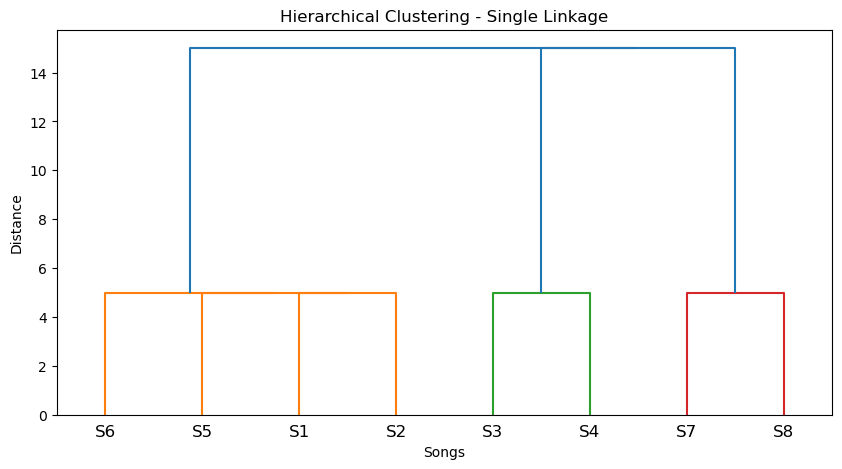

In [4]:
X = songs[["tempo", "energy"]].values

Z_single = linkage(X, method="single", metric="euclidean")

plt.figure(figsize=(10, 5))
dendrogram(Z_single, labels=songs["Song"].values)
plt.title("Hierarchical Clustering - Single Linkage")
plt.xlabel("Songs")
plt.ylabel("Distance")
plt.show()

## Task 3

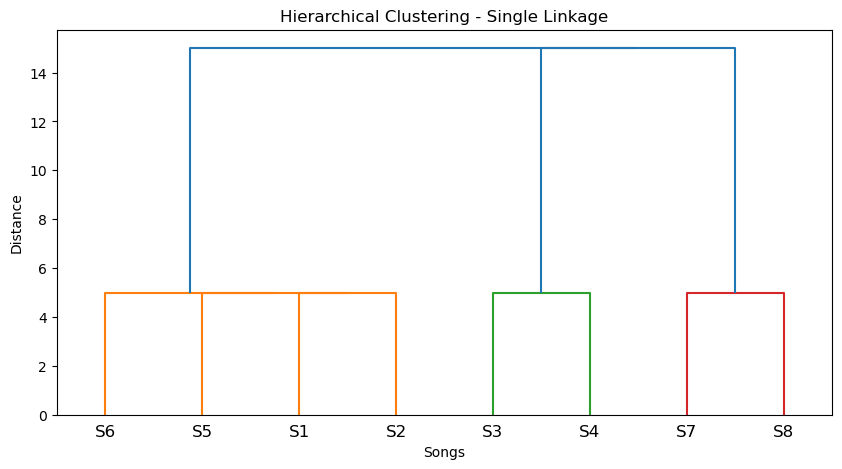

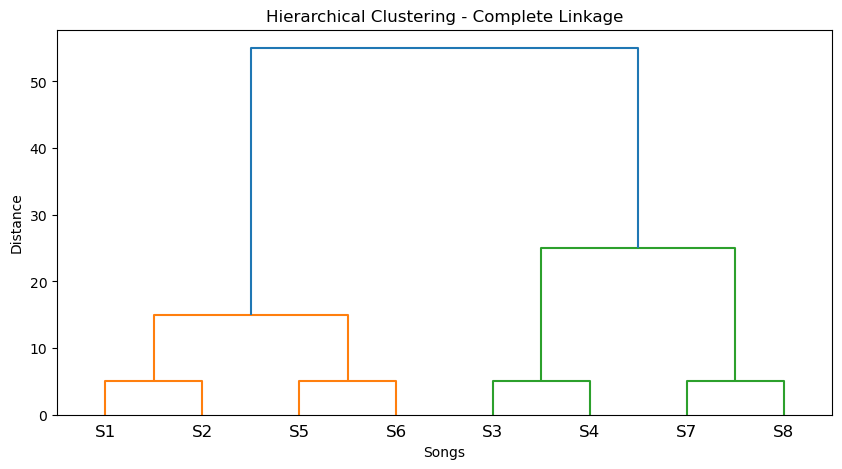

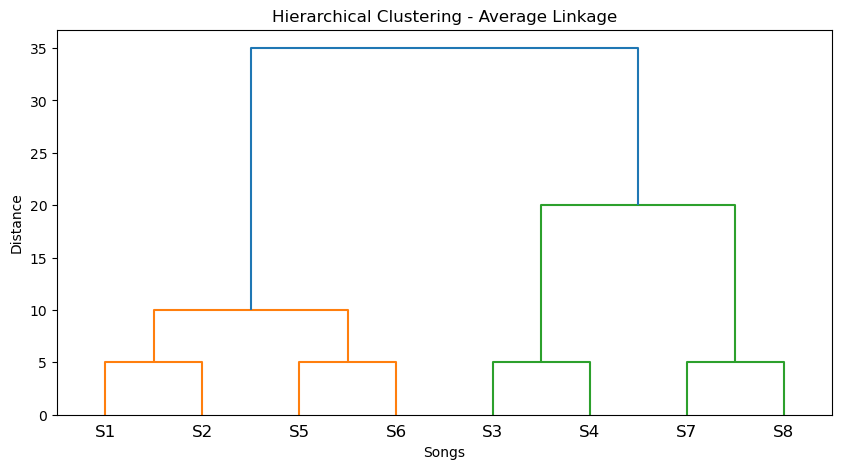

In [5]:
methods = ["single", "complete", "average"]

for method in methods:
    Z = linkage(X, method=method, metric="euclidean")

    plt.figure(figsize=(10, 5))
    dendrogram(Z, labels=songs["Song"].values)
    plt.title(f"Hierarchical Clustering - {method.capitalize()} Linkage")
    plt.xlabel("Songs")
    plt.ylabel("Distance")
    plt.show()

## Task 4

In [6]:
def calculate_distances(p1, p2):
    euclidean = np.sqrt((p2[0] - p1[0]) ** 2 + (p2[1] - p1[1]) ** 2)
    manhattan = abs(p2[0] - p1[0]) + abs(p2[1] - p1[1])
    return euclidean, manhattan

pairs = [
    ((25, 4), (30, 6)),
    ((20, 3), (35, 8)),
    ((28, 5), (22, 2))
]

results = []

for p1, p2 in pairs:
    euclidean, manhattan = calculate_distances(p1, p2)
    results.append({
        "Point 1": p1,
        "Point 2": p2,
        "Euclidean Distance": euclidean,
        "Manhattan Distance": manhattan
    })

pd.DataFrame(results).round(2)

,Point 1,Point 2,Euclidean Distance,Manhattan Distance
0,"(25, 4)","(30, 6)",5.39,7
1,"(20, 3)","(35, 8)",15.81,20
2,"(28, 5)","(22, 2)",6.71,9


## Task 5

For grouping movies by user ratings, I would choose average linkage. It gives a balanced measure of similarity between groups by considering the average distance between movies. This makes it less sensitive to extreme ratings than single linkage and less strict than complete linkage. Ward linkage is also useful when ratings are numeric and compact clusters are preferred, but average linkage is a good general choice for finding groups of movies with similar rating patterns.